#### Holt's Double Exponential Smoothing (HWES)
##### HWES is an extension of SES that adds the ability to also capture trend (whether prices are generally going up or down over time).
##### It uses two components:

##### Level --> where the data currently is (same as SES)
##### Trend --> the direction and speed the data is moving

##### This is why HWES can produce forecasts that slope up or down, rather than the flat forecast that SES gives.
##### The damped option is an extra control, if damped is True, the trend gradually flattens out over time instead of continuing indefinitely, which is often more realistic for stock prices.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-01,954.592529,966.058798,953.250218,963.715501,12534407
2021-07-02,968.743347,970.495163,952.317401,954.160205,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594


In [5]:
# The dataframe is not normal columns, it's a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,954.592529,966.058798,953.250218,963.715501,12534407
2021-07-02,968.743347,970.495163,952.317401,954.160205,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594
2022-01-24,1081.973145,1139.691425,1071.598850,1126.154703,21868937


In [7]:
stk_data = stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-07-01,963.715501,966.058798,953.250218,954.592529
2021-07-02,954.160205,970.495163,952.317401,968.743347
2021-07-05,972.110448,979.891169,969.858139,978.366882
2021-07-06,975.978096,977.775346,964.716550,966.809570
2021-07-07,968.151889,968.151889,954.615287,960.098145
...,...,...,...,...
2022-01-20,1137.552961,1142.057580,1117.054587,1127.269653
2022-01-21,1115.689559,1138.553855,1115.689559,1127.451538
2022-01-24,1126.154703,1139.691425,1071.598850,1081.973145


In [9]:
column = "Close"

In [14]:
# The default MinMaxScaler() scales data to [0, 1], meaning the minimum value becomes exactly 0.0. 
# Multiplicative trend in ExponentialSmoothing requires all values to be strictly greater than zero.
# It computes ratios, so division by zero is undefined. 
# Setting feature_range=(0.001, 1) shifts the floor up slightly, keeping all values positive while preserving the same relative scaling. 

from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler(feature_range=(0.001, 1))
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (144, 1)


In [15]:
len(data1)

144

In [16]:
training_size = round(len(data1) * 0.80)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [17]:
# Import required libraries
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from stockFunctions import rmsemape

# Define parameter combinations
trends = ['add', 'mul']          # additive or multiplicative trend
dampeds = [True, False]          # whether to damp the trend

# Loop through trend and damped combinations
for td in trends:

    for dp in dampeds:

        # Build model
        model = ExponentialSmoothing(X_train, trend=td, damped_trend=dp, seasonal=None)
        model_fit = model.fit(optimized=True)

        # Make predictions on test set
        y_pred = model_fit.forecast(len(X_test))

        # Print results
        print("Trend={}, Damped={}".format(td, dp))
        rmsemape(y_test, y_pred)
        print("*****************")

Trend=add, Damped=True
RMSE-Testset: 0.09739853366054368
MAPE-Testset: 0.15435279102837748
*****************
Trend=add, Damped=False
RMSE-Testset: 0.09458467219388586
MAPE-Testset: 0.15552137231971094
*****************
Trend=mul, Damped=True
RMSE-Testset: 0.10887101366992488
MAPE-Testset: 0.15821942575759335
*****************
Trend=mul, Damped=False
RMSE-Testset: 0.10886156793977016
MAPE-Testset: 0.15852558209859335
*****************


In [18]:
# Best model: Trend='add', Damped=False (example — choose based on lowest RMSE/MAPE from tuning above)
# Reason: Additive trend suits linear price movements; no damping keeps the trend active over forecast horizon

td = 'add'
dp = False

# Build model
model = ExponentialSmoothing(X_train, trend=td, damped_trend=dp, seasonal=None)
model_fit = model.fit(optimized=True)

# Make predictions
y_pred = model_fit.forecast(len(X_test))

print("Trend={}, Damped={}".format(td, dp))
rmsemape(y_test, y_pred)
print("*****************")

Trend=add, Damped=False
RMSE-Testset: 0.09458467219388586
MAPE-Testset: 0.15552137231971094
*****************


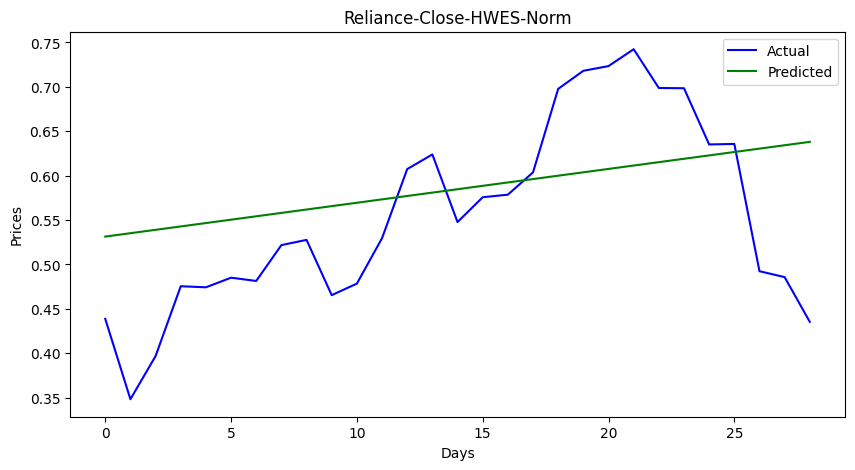

In [19]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-HWES-Norm", "Days", "Prices")

In [20]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [21]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

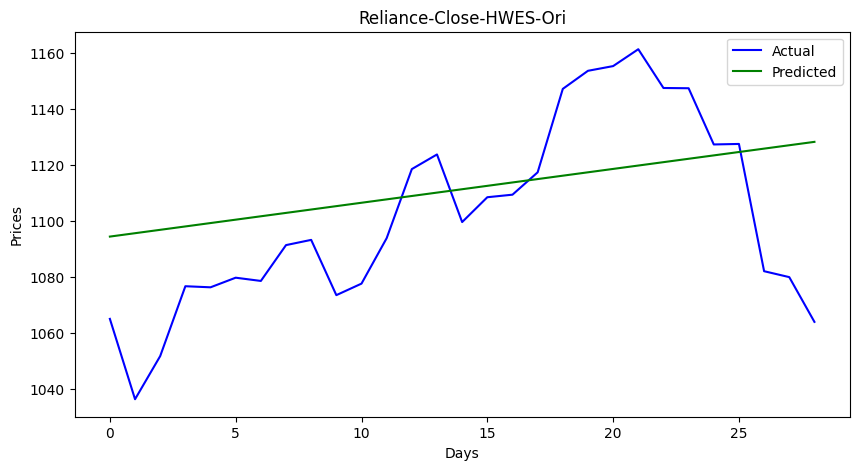

In [22]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-HWES-Ori",
      "Days",
      "Prices")

In [23]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

RMSE-Testset: 30.007546777041405
MAPE-Testset: 0.022832791045091817


In [24]:
# Forecast next 4 days beyond the dataset
forecast = model_fit.forecast(4)

In [25]:
forecast

array([0.53135706, 0.53516795, 0.53897884, 0.54278973])

In [26]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [27]:
forecast_stock_price_test_oriF

,Closefore
0,1094.344913
1,1095.553941
2,1096.762968
3,1097.971996


In [28]:
forecast_stock_price_test_oriF.to_csv("CloseHWES.csv", index=False)

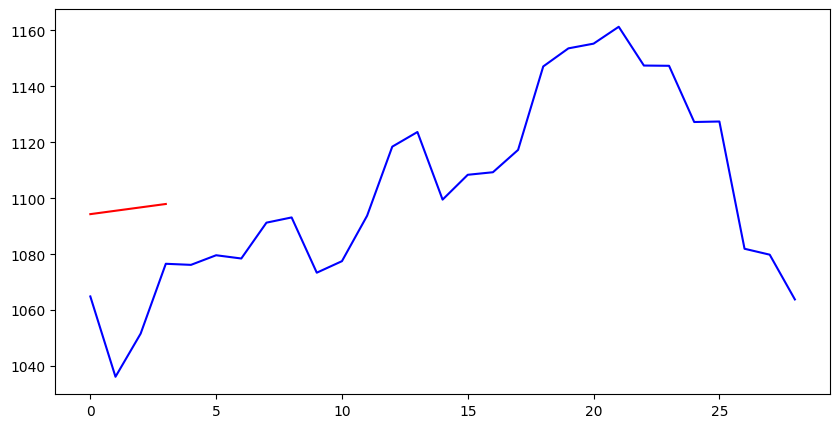

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA, color='blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color='red', label="Forecast")